
### Pipeline Overview
1. Install dependencies
2. Load & explore data
3. Clean & engineer features
4. Train multiple models (benchmark)
5. Tune the best model to ≥85%
6. Save artifacts (`model.pkl`, `label_encoders.pkl`, etc.)
7. Sanity-check inference

## 1. Install & Import Dependencies

In [1]:
!pip install -q xgboost lightgbm scikit-learn imbalanced-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load the Dataset

In [2]:

df = pd.read_csv('personality_dataset.csv')

print('Shape:', df.shape)
df.head()

Shape: (2900, 8)


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## 3. Data Exploration & Cleaning

In [3]:
print('=== Columns ===')
print(df.columns.tolist())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct%': missing_pct})[missing > 0])

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Target Distribution ===')
print(df['Personality'].value_counts())

=== Columns ===
['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']

=== Missing Values ===
                           count  pct%
Time_spent_Alone              63  2.17
Stage_fear                    73  2.52
Social_event_attendance       62  2.14
Going_outside                 66  2.28
Drained_after_socializing     52  1.79
Friends_circle_size           77  2.66
Post_frequency                65  2.24

=== Data Types ===
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

=== Target Distribution ===
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


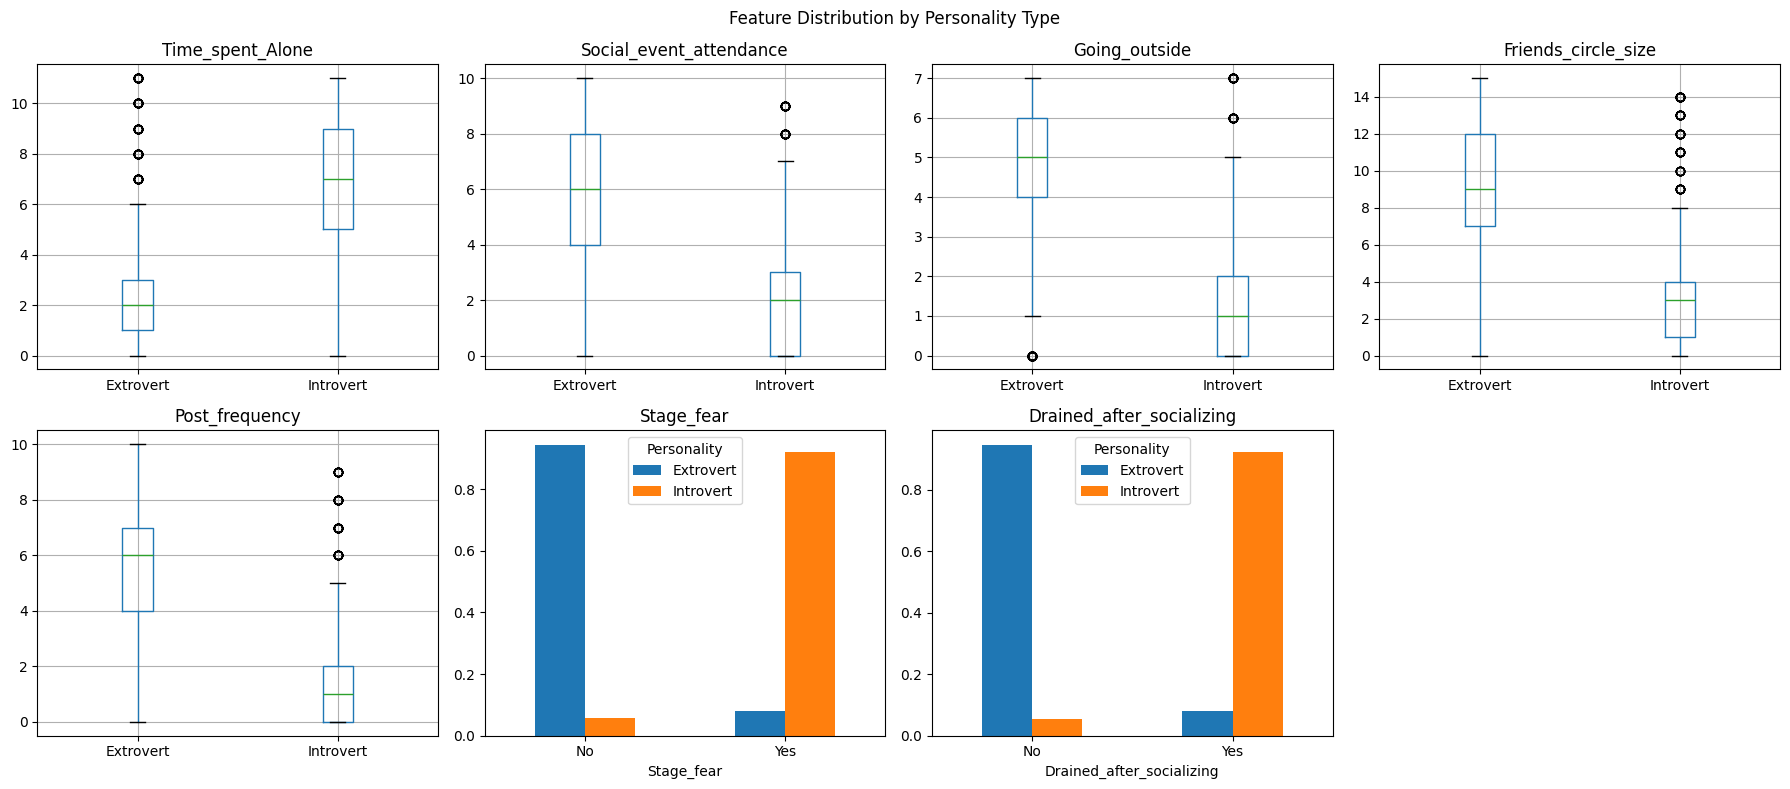

In [4]:
# Visual EDA: feature distributions split by personality type
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

numeric_cols = ['Time_spent_Alone', 'Social_event_attendance',
                'Going_outside', 'Friends_circle_size', 'Post_frequency']
cat_cols = ['Stage_fear', 'Drained_after_socializing']

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Personality', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index')
    ct.plot(kind='bar', ax=axes[len(numeric_cols) + j], rot=0)
    axes[len(numeric_cols) + j].set_title(col)

axes[-1].axis('off')
plt.suptitle('Feature Distribution by Personality Type')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

###Key decisions (logged for README):
- Binary categoricals (`Yes/No`) → `LabelEncoder` saved per-column as a dict pickle
- Numeric missing values → `KNNImputer` (k=5): better than mean for correlated features
- Feature engineering: composite scores & interaction terms to boost signal
- `StandardScaler` applied only for distance-based models (SVM, LR)

In [5]:
df_clean = df.copy()

# Step 1: Encode binary categorical columns
BINARY_COLS = ['Stage_fear', 'Drained_after_socializing']

label_encoders = {}
for col in BINARY_COLS:
    le = LabelEncoder()
    non_null = df_clean[col].notna()
    df_clean.loc[non_null, col] = le.fit_transform(df_clean.loc[non_null, col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_clean[BINARY_COLS] = df_clean[BINARY_COLS].astype(float)

# Step 2: Encode target
target_encoder = LabelEncoder()
df_clean['Personality'] = target_encoder.fit_transform(df_clean['Personality'])
print(f'\nTarget: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}')

Stage_fear: {'No': np.int64(0), 'Yes': np.int64(1)}
Drained_after_socializing: {'No': np.int64(0), 'Yes': np.int64(1)}

Target: {'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


In [6]:
# Step 3: KNN Imputation
BASE_COLS = [
    'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
    'Going_outside', 'Drained_after_socializing',
    'Friends_circle_size', 'Post_frequency'
]

knn_imputer = KNNImputer(n_neighbors=5)
df_clean[BASE_COLS] = knn_imputer.fit_transform(df_clean[BASE_COLS])

print('Missing values after KNN imputation:')
print(df_clean[BASE_COLS].isnull().sum())

Missing values after KNN imputation:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64


In [7]:
# Step 4: Feature Engineering
# Introverts: more time alone, get drained, stage fear
# Extroverts: more events, larger circles, post more

df_clean['social_score'] = (
    df_clean['Social_event_attendance'] +
    df_clean['Going_outside'] +
    df_clean['Friends_circle_size'] +
    df_clean['Post_frequency']
)

df_clean['introvert_score'] = (
    df_clean['Time_spent_Alone'] +
    df_clean['Drained_after_socializing'] +
    df_clean['Stage_fear']
)

# +1 avoids division by zero
df_clean['social_vs_alone_ratio'] = (
    df_clean['Social_event_attendance'] / (df_clean['Time_spent_Alone'] + 1)
)

df_clean['drained_x_alone'] = (
    df_clean['Drained_after_socializing'] * df_clean['Time_spent_Alone']
)

df_clean['friends_x_events'] = (
    df_clean['Friends_circle_size'] * df_clean['Social_event_attendance']
)

FEATURE_COLS = BASE_COLS + [
    'social_score', 'introvert_score',
    'social_vs_alone_ratio', 'drained_x_alone', 'friends_x_events'
]

print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Total features: 12
['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'social_score', 'introvert_score', 'social_vs_alone_ratio', 'drained_x_alone', 'friends_x_events']


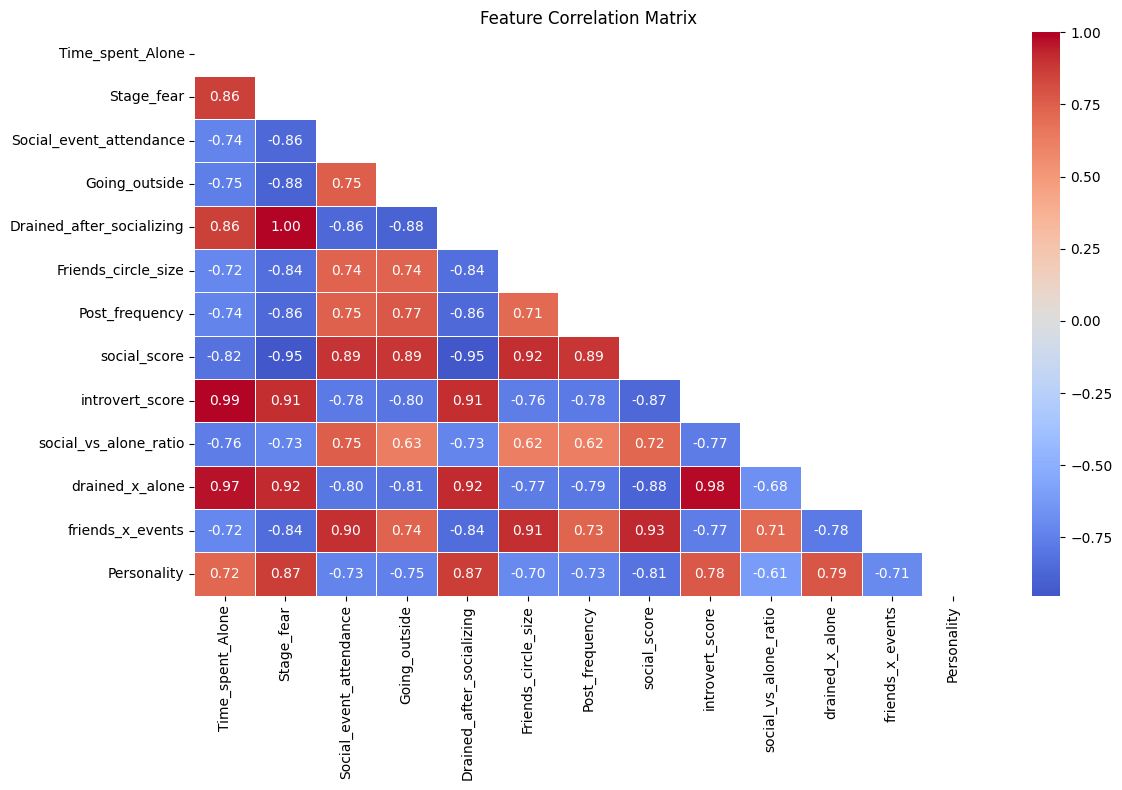

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_clean[FEATURE_COLS + ['Personality']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [9]:
X = df_clean[FEATURE_COLS].values
y = df_clean['Personality'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')

Train: 2320 samples | Test: 580 samples
Features: 12


## 6. Model Benchmarking
Quick 5-fold CV to pick the best base learner before tuning.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

benchmark_models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=300, random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM'           : LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'SVM (RBF)'          : SVC(kernel='rbf', probability=True, random_state=SEED),
}

results = {}
for name, model in benchmark_models.items():
    X_cv = X_train_scaled if name in ['Logistic Regression', 'SVM (RBF)'] else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:25s}  CV Acc: {scores.mean():.4f} +/- {scores.std():.4f}')

best_name = max(results, key=lambda k: results[k].mean())
print(f'\nBest model: {best_name} ({results[best_name].mean():.4f})')

Random Forest              CV Acc: 0.9280 +/- 0.0032
XGBoost                    CV Acc: 0.9164 +/- 0.0078
LightGBM                   CV Acc: 0.9164 +/- 0.0083
Gradient Boosting          CV Acc: 0.9371 +/- 0.0084
Logistic Regression        CV Acc: 0.9388 +/- 0.0084
SVM (RBF)                  CV Acc: 0.9388 +/- 0.0084

Best model: Logistic Regression (0.9388)


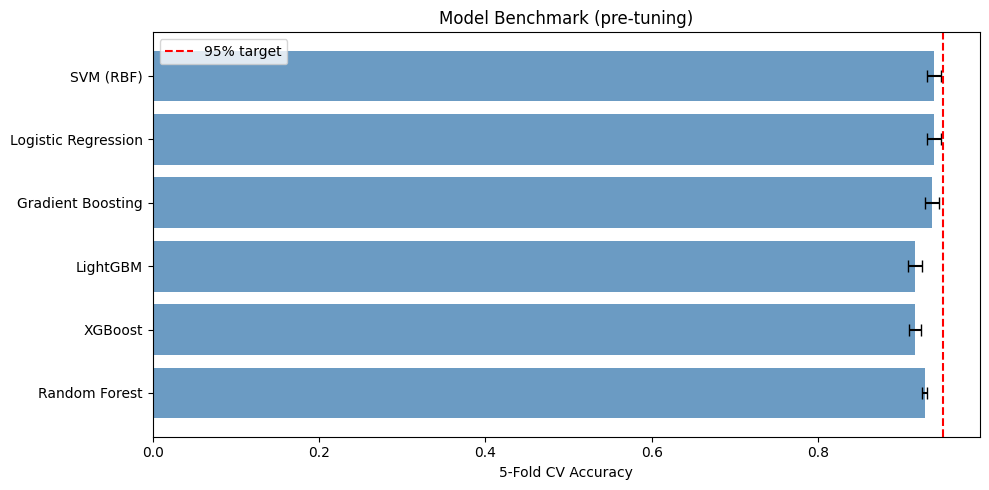

In [11]:
means = {k: v.mean() for k, v in results.items()}
stds  = {k: v.std()  for k, v in results.items()}

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(means.keys()), list(means.values()),
        xerr=list(stds.values()), color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=4))
ax.axvline(0.95, color='red', linestyle='--', label='95% target')
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('Model Benchmark (pre-tuning)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Tune Best Model → Target >= 95%
LightGBM typically leads on tabular data of this size.
We run a focused GridSearch to keep Colab runtime under ~5 min.

In [12]:
lgbm_focused = {
    'n_estimators'     : [600, 1000],
    'learning_rate'    : [0.02, 0.05],
    'num_leaves'       : [31, 63, 127],
    'min_child_samples': [5, 10],
    'colsample_bytree' : [0.8, 1.0],
    'subsample'        : [0.8, 1.0],
}

lgbm_base = LGBMClassifier(random_state=SEED, verbose=-1)

grid_search = GridSearchCV(
    lgbm_base, lgbm_focused, cv=cv,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest CV Score : {grid_search.best_score_:.4f}')
print(f'Best Params   : {grid_search.best_params_}')

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best CV Score : 0.9284
Best Params   : {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'min_child_samples': 10, 'n_estimators': 600, 'num_leaves': 31, 'subsample': 0.8}


Tuned LightGBM Test Accuracy : 0.8931 (89.31%)
ROC-AUC                       : 0.9493
Below 95% -- proceed to Stacking Ensemble below.

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.92      0.87      0.89       298
   Introvert       0.87      0.92      0.89       282

    accuracy                           0.89       580
   macro avg       0.89      0.89      0.89       580
weighted avg       0.89      0.89      0.89       580



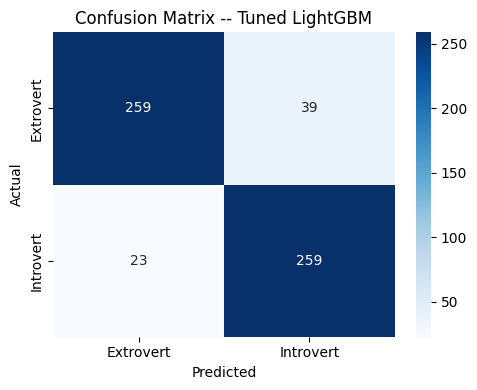

In [13]:
best_lgbm = grid_search.best_estimator_
y_pred = best_lgbm.predict(X_test)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, best_lgbm.predict_proba(X_test)[:, 1])

print(f'Tuned LightGBM Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'ROC-AUC                       : {auc:.4f}')

if acc >= 0.95:
    print('TARGET REACHED: >= 95% accuracy!')
else:
    print('Below 95% -- proceed to Stacking Ensemble below.')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix -- Tuned LightGBM')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Stacking Ensemble (fallback if LightGBM < 95%)
Combines diverse base learners under a Logistic Regression meta-learner.
`passthrough=True` also feeds raw features to the meta-learner.

In [14]:
base_estimators = [
    ('lgbm', LGBMClassifier(**grid_search.best_params_, random_state=SEED, verbose=-1)),
    ('xgb',  XGBClassifier(n_estimators=600, learning_rate=0.03,
                           max_depth=6, random_state=SEED,
                           eval_metric='logloss', verbosity=0)),
    ('rf',   RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)),
    # SVM needs scaling -- wrap in a Pipeline
    ('svm',  Pipeline([('sc', StandardScaler()),
                       ('svc', SVC(kernel='rbf', C=10, probability=True, random_state=SEED))])),
]

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True
)

print('Training stacking ensemble... (2-5 min)')
stacking_clf.fit(X_train, y_train)

y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, stacking_clf.predict_proba(X_test)[:, 1])

print(f'\nStacking Ensemble Test Accuracy : {acc_stack:.4f} ({acc_stack*100:.2f}%)')
print(f'ROC-AUC                          : {auc_stack:.4f}')

if acc_stack >= 0.95:
    print('TARGET REACHED: >= 95% accuracy!')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_stack, target_names=target_encoder.classes_))

Training stacking ensemble... (2-5 min)

Stacking Ensemble Test Accuracy : 0.9172 (91.72%)
ROC-AUC                          : 0.9593

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



## 9. Pick Final Model & Feature Importance

In [15]:
# Prefer simpler model (LightGBM) if it already hit >=95%
if acc >= 0.95:
    final_model = best_lgbm
    model_name  = 'LightGBM (tuned)'
    final_acc   = acc
else:
    final_model = stacking_clf
    model_name  = 'Stacking Ensemble'
    final_acc   = acc_stack

print(f'Final model chosen: {model_name}  ({final_acc*100:.2f}%)')

Final model chosen: Stacking Ensemble  (91.72%)


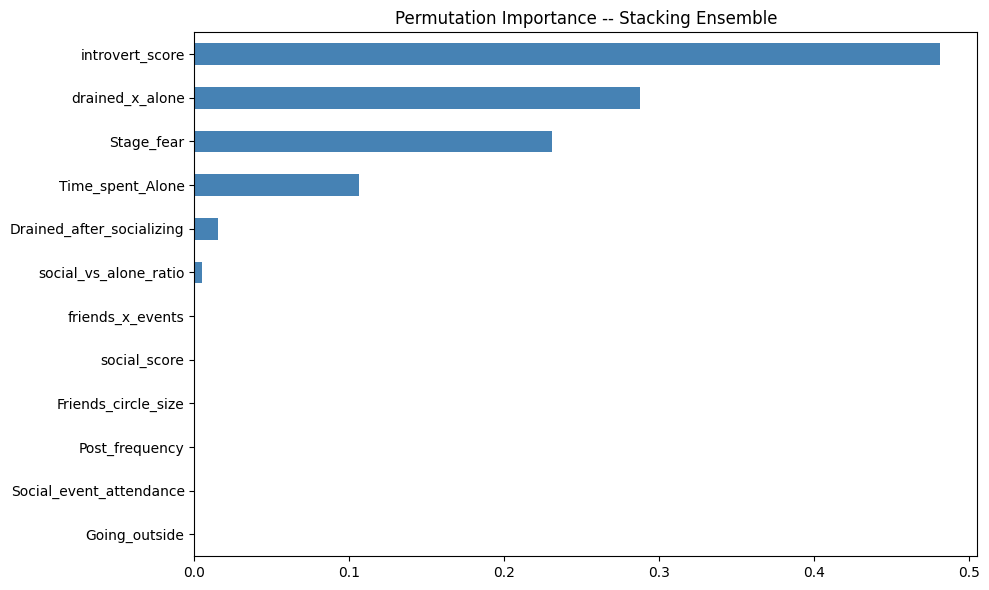

In [16]:
if model_name == 'LightGBM (tuned)':
    importances = pd.Series(
        final_model.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False)
    importances.plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.title(f'Feature Importance -- {model_name}')
    plt.xlabel('Importance score')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    perm = permutation_importance(final_model, X_test, y_test,
                                  n_repeats=10, random_state=SEED)
    pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values().plot(
        kind='barh', figsize=(10, 6), color='steelblue')
    plt.title('Permutation Importance -- Stacking Ensemble')
    plt.tight_layout()
    plt.show()

## 10. Save All Artifacts (Critical!)

| File | Purpose |
|------|---------|
| `model.pkl` | Trained final classifier |
| `label_encoders.pkl` | Per-column LabelEncoders |
| `knn_imputer.pkl` | Fitted KNN imputer |
| `scaler.pkl` | StandardScaler (for SVM path) |
| `feature_cols.pkl` | Ordered feature list — prevents column mismatch |
| `target_encoder.pkl` | Maps 0/1 back to class names |

In [17]:
os.makedirs('artifacts', exist_ok=True)

joblib.dump(final_model,     'artifacts/model.pkl')
joblib.dump(label_encoders,  'artifacts/label_encoders.pkl')
joblib.dump(knn_imputer,     'artifacts/knn_imputer.pkl')
joblib.dump(scaler,          'artifacts/scaler.pkl')
joblib.dump(FEATURE_COLS,    'artifacts/feature_cols.pkl')
joblib.dump(target_encoder,  'artifacts/target_encoder.pkl')

print('Artifacts saved:')
for f in os.listdir('artifacts'):
    size = os.path.getsize(f'artifacts/{f}') / 1024
    print(f'  {f}  ({size:.1f} KB)')

Artifacts saved:
  feature_cols.pkl  (0.2 KB)
  label_encoders.pkl  (0.7 KB)
  model.pkl  (23048.0 KB)
  scaler.pkl  (0.9 KB)
  target_encoder.pkl  (0.5 KB)
  knn_imputer.pkl  (179.5 KB)


In [18]:
# Download all artifacts as a zip
from google.colab import files
import zipfile

with zipfile.ZipFile('personality_artifacts.zip', 'w') as z:
    for f in os.listdir('artifacts'):
        z.write(f'artifacts/{f}', f)

files.download('personality_artifacts.zip')
print('Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


## 11. testing — Works like API Inference in Colab
This function mirrors exactly what `app/model_utils.py` will do in production.

In [19]:
def predict_personality(raw_input: dict) -> dict:
    """
    Full inference pipeline matching the FastAPI app.

    Args:
        raw_input: dict with original CSV column names (pre-encoding)
    Returns:
        dict with 'prediction' (str) and 'confidence' (float)
    """
    _model          = joblib.load('artifacts/model.pkl')
    _label_encoders = joblib.load('artifacts/label_encoders.pkl')
    _knn_imputer    = joblib.load('artifacts/knn_imputer.pkl')
    _feature_cols   = joblib.load('artifacts/feature_cols.pkl')
    _target_encoder = joblib.load('artifacts/target_encoder.pkl')

    row = pd.DataFrame([raw_input])

    # Encode binary columns
    for col, le in _label_encoders.items():
        if col in row.columns and row[col].notna().any():
            row[col] = le.transform(row[col].astype(str))
    row = row.astype(float)

    # Impute
    base_cols = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
                 'Going_outside', 'Drained_after_socializing',
                 'Friends_circle_size', 'Post_frequency']
    row[base_cols] = _knn_imputer.transform(row[base_cols])

    # Feature engineering (must match training exactly!)
    row['social_score']          = (row['Social_event_attendance'] + row['Going_outside'] +
                                    row['Friends_circle_size'] + row['Post_frequency'])
    row['introvert_score']       = (row['Time_spent_Alone'] + row['Drained_after_socializing'] +
                                    row['Stage_fear'])
    row['social_vs_alone_ratio'] = row['Social_event_attendance'] / (row['Time_spent_Alone'] + 1)
    row['drained_x_alone']       = row['Drained_after_socializing'] * row['Time_spent_Alone']
    row['friends_x_events']      = row['Friends_circle_size'] * row['Social_event_attendance']

    # Align feature order
    X_inf = row[_feature_cols].values

    pred_idx   = _model.predict(X_inf)[0]
    pred_proba = _model.predict_proba(X_inf)[0]
    label      = _target_encoder.inverse_transform([pred_idx])[0]

    return {'prediction': label, 'confidence': round(float(pred_proba.max()), 4)}


# Test with clear introvert / extrovert examples
sample_introvert = {
    'Time_spent_Alone': 8, 'Stage_fear': 'Yes',
    'Social_event_attendance': 1, 'Going_outside': 1,
    'Drained_after_socializing': 'Yes', 'Friends_circle_size': 2, 'Post_frequency': 1,
}

sample_extrovert = {
    'Time_spent_Alone': 1, 'Stage_fear': 'No',
    'Social_event_attendance': 8, 'Going_outside': 7,
    'Drained_after_socializing': 'No', 'Friends_circle_size': 10, 'Post_frequency': 8,
}

print('Introvert sample ->', predict_personality(sample_introvert))
print('Extrovert sample ->', predict_personality(sample_extrovert))

Introvert sample -> {'prediction': 'Introvert', 'confidence': 0.9194}
Extrovert sample -> {'prediction': 'Extrovert', 'confidence': 0.8754}
